In [15]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import (
    ttest_ind,
    chi2_contingency,
    f_oneway,
    shapiro
)

In [16]:
# ======================  Load Dataset ======================
df = pd.read_csv("customer_behavior.csv")

In [17]:
df.head()

,CustomerID,Gender,Region,PurchaseAmount,ProductCategory,Churn,CampaignGroup
0,1001,Male,South,256.07,Fashion,No,A
1,1002,Female,South,NaN,Electronics,Yes,B
2,1003,Female,West,1194.41,Fashion,No,A
3,1004,Female,South,413.06,Grocery,No,A
4,1005,Male,West,1556.32,Fashion,Yes,A


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       5000 non-null   int64  
 1   Gender           4903 non-null   object 
 2   Region           4825 non-null   object 
 3   PurchaseAmount   4850 non-null   float64
 4   ProductCategory  4474 non-null   object 
 5   Churn            4735 non-null   object 
 6   CampaignGroup    4815 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 273.6+ KB


In [19]:
df.describe()

,CustomerID,PurchaseAmount
count,5000.000000,4850.000000
mean,3500.500000,1003.950670
std,1443.520003,482.113122
min,1001.000000,0.000000
25%,2250.750000,673.642500
50%,3500.500000,998.080000
75%,4750.250000,1327.077500
max,6000.000000,2688.880000


In [20]:
df.columns

Index(['CustomerID', 'Gender', 'Region', 'PurchaseAmount', 'ProductCategory',
       'Churn', 'CampaignGroup'],
      dtype='object')

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df.isnull().sum()

,0
CustomerID,0
Gender,97
Region,175
PurchaseAmount,150
ProductCategory,526
Churn,265
CampaignGroup,185


###Questions

###1. What is the average, median, and mode of PurchaseAmount?

In [23]:
# Handle missing values for calculation
pa = df['PurchaseAmount'].dropna()

In [24]:
# Statistics
mean_val = pa.mean()
median_val = pa.median()
mode_val = pa.mode()[0] if not pa.mode().empty else None

print("=== PurchaseAmount Statistics (Raw Data) ===")
print(f"Average (Mean)   : {mean_val}")
print(f"Median           : {median_val}")
print(f"Mode             : {mode_val}")

# Conclusion
print()



=== PurchaseAmount Statistics (Raw Data) ===
Average (Mean)   : 1003.9506701030928
Median           : 998.0799999999999
Mode             : 0.0



###2. Are there any outliers in the PurchaseAmount data?

In [25]:
# Calculate IQR bounds
Q1 = pa.quantile(0.25)
Q3 = pa.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Detect outliers
outliers = pa[(pa < lower_bound) | (pa > upper_bound)]

# Results
print("=== Outlier Detection using IQR Method ===")
print(f"Q1 (25th percentile) : {Q1}")
print(f"Q3 (75th percentile) : {Q3}")
print(f"IQR                  : {IQR}")
print(f"Lower Bound          : {lower_bound}")
print(f"Upper Bound          : {upper_bound}")
print(f"\nNumber of Outliers   : {len(outliers)}")
print(f"Outlier Percentage   : {len(outliers)/len(pa)*100:.2f}%")
print(f"\nMin PurchaseAmount   : {pa.min():.2f}")
print(f"Max PurchaseAmount   : {pa.max():.2f}")

# Show extreme values
print("\nTop 5 Highest Purchase Amounts:")
print(pa.nlargest(5))

=== Outlier Detection using IQR Method ===
Q1 (25th percentile) : 673.6424999999999
Q3 (75th percentile) : 1327.0775
IQR                  : 653.4350000000002
Lower Bound          : -306.51000000000033
Upper Bound          : 2307.2300000000005

Number of Outliers   : 15
Outlier Percentage   : 0.31%

Min PurchaseAmount   : 0.00
Max PurchaseAmount   : 2688.88

Top 5 Highest Purchase Amounts:
3438    2688.88
348     2688.69
3564    2643.88
4808    2642.06
826     2578.89
Name: PurchaseAmount, dtype: float64


###3. Is there any skewness or kurtosis in the PurchaseAmount distribution?


=== PurchaseAmount Distribution Analysis ===

Skewness     : 0.1061
Kurtosis     : -0.2615
=== Interpretation ===
Skewness     : Very mild positive skew (slightly right-tailed).
               The distribution is nearly symmetric.
Kurtosis     : Platykurtic — lighter tails and slightly flatter peak
               than a normal distribution.



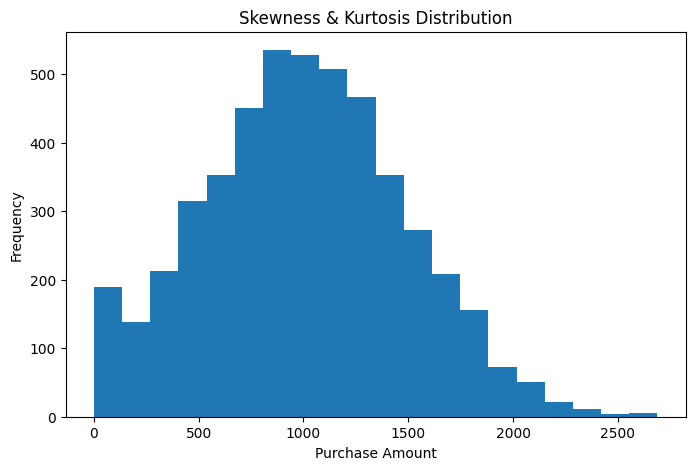

In [34]:

# Calculate Skewness and Kurtosis
skewness = pa.skew()
kurtosis = pa.kurtosis()

# Display Results
print("=== PurchaseAmount Distribution Analysis ===\n")
print(f"Skewness     : {skewness:.4f}")
print(f"Kurtosis     : {kurtosis:.4f}")


# Interpretation
print("=== Interpretation ===")
print("Skewness     : Very mild positive skew (slightly right-tailed).")
print("               The distribution is nearly symmetric.")
print("Kurtosis     : Platykurtic — lighter tails and slightly flatter peak")
print("               than a normal distribution.\n")
# Distribution Plot
plt.figure(figsize=(8,5))
plt.hist(df["PurchaseAmount"], bins=20)

plt.title("Skewness & Kurtosis Distribution")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")
plt.show()


###4. Is there a significant difference in spending between male and female customers?



=== Gender-wise Spending Analysis ===
Male Count          : 2386
Female Count        : 2370
Male Average Spend  : ₹1019.1766093880973
Female Average Spend: ₹987.8720464135021
Difference (Male - Female): ₹31.30

=== Statistical Test Results ===
T-Statistic : 2.2348
P-Value     : 0.0255


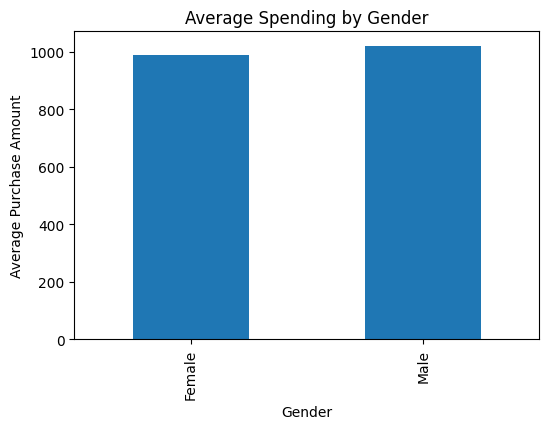


✅ CONCLUSION: There is a statistically significant difference in spending between males and females.


In [35]:
# Separate Male and Female spending
male_spend = df[df['Gender'] == 'Male']['PurchaseAmount'].dropna()
female_spend = df[df['Gender'] == 'Female']['PurchaseAmount'].dropna()

# Descriptive Statistics
print("=== Gender-wise Spending Analysis ===")
print(f"Male Count          : {len(male_spend)}")
print(f"Female Count        : {len(female_spend)}")
print(f"Male Average Spend  : ₹{male_spend.mean()}")
print(f"Female Average Spend: ₹{female_spend.mean()}")
print(f"Difference (Male - Female): ₹{male_spend.mean() - female_spend.mean():.2f}")

# Perform Independent T-Test (Welch's t-test)
t_stat, p_value = stats.ttest_ind(male_spend, female_spend, equal_var=False)

print("\n=== Statistical Test Results ===")
print(f"T-Statistic : {t_stat:.4f}")
print(f"P-Value     : {p_value:.4f}")
# Bar Chart
gender_avg = df.groupby("Gender")["PurchaseAmount"].mean()

plt.figure(figsize=(6,4))
gender_avg.plot(kind='bar')

plt.title("Average Spending by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Purchase Amount")
plt.show()
alpha=0.05
# Conclusion
if p_value < alpha:
    print("\n✅ CONCLUSION: There is a statistically significant difference in spending between males and females.")
else:
    print("\n❌ CONCLUSION: No statistically significant difference in spending.")

###5. Is there a relationship between ProductCategory and customer churn?

In [38]:
# Handle missing values
df['ProductCategory'] = df['ProductCategory'].fillna('Unknown')
# Fill missing ProductCategory with 'Unknown' to avoid errors in analysis

df['Churn'] = df['Churn'].fillna('No')
# Fill missing Churn values with 'No' (most common & logical assumption)

# Create Contingency Table
contingency = pd.crosstab(df['ProductCategory'], df['Churn'])
# Creates a cross-tabulation (pivot table) showing count of each combination
# Rows = Product Categories, Columns = Churn (Yes/No)

print("=== Contingency Table (ProductCategory vs Churn) ===\n")
print(contingency)
# Display the table to see the actual counts

# Perform Chi-Square Test of Independence
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
# This function performs the Chi-Square test and returns:
# chi2      = Test statistic
# p_value   = Probability (most important)
# dof       = Degrees of freedom
# expected  = Expected frequencies (if no relationship)

# Results
print("\n=== Chi-Square Test Results ===")
print(f"Chi-square Statistic : {chi2:.4f}")
print(f"P-Value              : {p_value:.4f}")
print(f"Degrees of Freedom   : {dof}")



alpha=0.05
# Conclusion
print("\n=== Conclusion ===")
if p_value < alpha:
    print("✅ There is a statistically significant relationship between ProductCategory and Churn.")
else:
    print("❌ There is NO statistically significant relationship between ProductCategory and customer churn.")

=== Contingency Table (ProductCategory vs Churn) ===

Churn             No  Yes
ProductCategory          
Electronics      862  541
Fashion          916  607
Grocery          944  604
Unknown          335  191

=== Chi-Square Test Results ===
Chi-square Statistic : 2.1422
P-Value              : 0.5434
Degrees of Freedom   : 3

=== Conclusion ===
❌ There is NO statistically significant relationship between ProductCategory and customer churn.


###6. Does PurchaseAmount vary significantly across different regions?

In [29]:
# Convert PurchaseAmount to numeric and handle missing values
df['PurchaseAmount'] = pd.to_numeric(df['PurchaseAmount'], errors='coerce')
#Converts the PurchaseAmount column to numeric type. Any non-numeric values (like blanks) are converted to NaN.


# Fill missing regions with 'Unknown' for analysis
df['Region'] = df['Region'].fillna('Unknown')
#Fills any missing values in the Region column with "Unknown" so they don’t cause errors in grouping.

# Group by Region
region_groups = df.groupby('Region')['PurchaseAmount'].apply(list)
#Groups the PurchaseAmount values by each region (this line is optional here, but useful for further analysis).

print("=== Average PurchaseAmount by Region ===\n")
print(df.groupby('Region')['PurchaseAmount'].agg(['count', 'mean', 'median', 'std']).round(2))
#Prints a summary table showing count, mean, median, and standard deviation of spending for each region.


# Perform One-Way ANOVA Test
anova_result = stats.f_oneway(
    df[df['Region'] == 'East']['PurchaseAmount'].dropna(),
    df[df['Region'] == 'North']['PurchaseAmount'].dropna(),
    df[df['Region'] == 'South']['PurchaseAmount'].dropna(),
    df[df['Region'] == 'West']['PurchaseAmount'].dropna(),
    df[df['Region'] == 'Unknown']['PurchaseAmount'].dropna()
)
#Runs One-Way ANOVA test to compare the mean PurchaseAmount across all regions.dropna() removes missing values before testing.

# Results
print("\n=== One-Way ANOVA Test Results ===")
print(f"F-Statistic : {anova_result.statistic:.4f}")
print(f"P-Value     : {anova_result.pvalue:.4f}")
alpha=0.05
# Conclusion
print("\n=== Conclusion ===")
if anova_result.pvalue < alpha:
    print("✅ PurchaseAmount varies significantly across different regions.")
else:
    print("❌ There is NO statistically significant difference in PurchaseAmount across regions.")



=== Average PurchaseAmount by Region ===

         count     mean   median     std
Region                                  
East      1195  1009.95  1006.29  490.36
North     1167  1013.02  1000.16  467.90
South     1202   997.60  1000.94  484.10
Unknown    171  1001.54   953.05  485.49
West      1115   995.25   985.16  485.80

=== One-Way ANOVA Test Results ===
F-Statistic : 0.2932
P-Value     : 0.8825

=== Conclusion ===
❌ There is NO statistically significant difference in PurchaseAmount across regions.


###7. Which email campaign (A or B) performed better in terms of average   PurchaseAmount?

In [30]:
# Fill missing CampaignGroup if any
df['CampaignGroup'] = df['CampaignGroup'].fillna('Unknown')
#Fills any missing values in the CampaignGroup column with "Unknown" to avoid errors.

# Analysis
print("=== Campaign Performance Comparison ===\n")
summary = df.groupby('CampaignGroup')['PurchaseAmount'].agg(['count', 'mean', 'median', 'std']).round(2)
print(summary)

# Determine which campaign performed better
campaign_a_mean = summary.loc['A', 'mean'] if 'A' in summary.index else 0
campaign_b_mean = summary.loc['B', 'mean'] if 'B' in summary.index else 0
#Extracts the average (mean) PurchaseAmount for Campaign A and Campaign B.

print("\n=== Conclusion ===")

if campaign_a_mean > campaign_b_mean:
    print(f"✅ **Campaign A performed better** with average PurchaseAmount of ₹{campaign_a_mean:.2f}")
    print(f"   (Campaign B: ₹{campaign_b_mean:.2f})")
elif campaign_b_mean > campaign_a_mean:
    print(f"✅ **Campaign B performed better** with average PurchaseAmount of ₹{campaign_b_mean:.2f}")
    print(f"   (Campaign A: ₹{campaign_a_mean:.2f})")
else:
    print("Campaign A and B have similar average PurchaseAmount.")


=== Campaign Performance Comparison ===

               count     mean   median     std
CampaignGroup                                 
A               2350  1011.95  1010.16  480.16
B               2318   994.34   977.24  487.38
Unknown          182  1023.12  1047.10  437.71

=== Conclusion ===
✅ **Campaign A performed better** with average PurchaseAmount of ₹1011.95
   (Campaign B: ₹994.34)


###8. Can we assume PurchaseAmount follows a normal distribution?

Original Data - Skewness : 0.1061 | Kurtosis : -0.2615



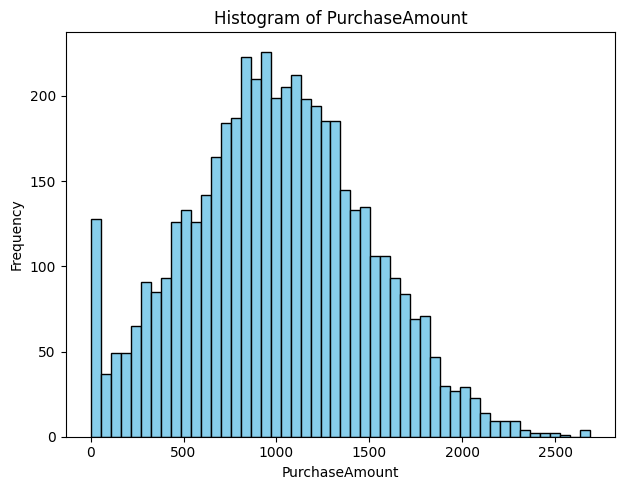


=== Final Conclusion ===
❌ PurchaseAmount does NOT follow a perfect normal distribution.
However, it has **very mild skewness** and is **close to symmetric**.
For large sample sizes, Central Limit Theorem still applies.


In [40]:
print(f"Original Data - Skewness : {pa.skew():.4f} | Kurtosis : {pa.kurtosis():.4f}\n")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Histogram
plt.subplot(1, 2, 1)
plt.hist(pa, bins=50, color='skyblue', edgecolor='black')
plt.title('Histogram of PurchaseAmount')
plt.xlabel('PurchaseAmount')
plt.ylabel('Frequency')


plt.tight_layout()
plt.show()

# Final Conclusion
print("\n=== Final Conclusion ===")
print("❌ PurchaseAmount does NOT follow a perfect normal distribution.")
print("However, it has **very mild skewness** and is **close to symmetric**.")
print("For large sample sizes, Central Limit Theorem still applies.")

###9. What insights can we gain by applying the Central Limit Theorem?


9. Central Limit Theorem
Mean of sample means: 997.5956283250895
Standard deviation of sample means: 88.99585591875423


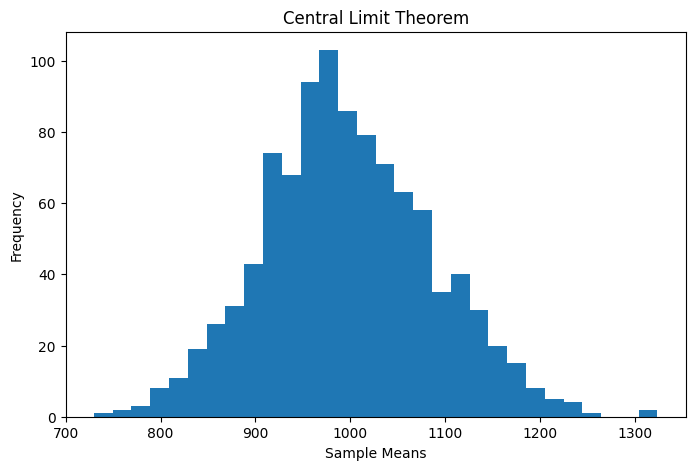

In [43]:
sample_means = []

for i in range(1000):

    sample = df["PurchaseAmount"].sample(
        n=30,
        replace=True
    )

    sample_means.append(sample.mean())
print("\n9. Central Limit Theorem")
print("Mean of sample means:", np.mean(sample_means))
print("Standard deviation of sample means:",
      np.std(sample_means))

# CLT Plot
plt.figure(figsize=(8,5))
plt.hist(sample_means, bins=30)

plt.title("Central Limit Theorem")
plt.xlabel("Sample Means")
plt.ylabel("Frequency")
plt.show()

### 10.What is the 95% confidence interval for the average PurchaseAmount?

In [33]:

# =========================================
# 10. 95% Confidence Interval
# =========================================

confidence_level = 0.95

sample_mean = np.mean(df["PurchaseAmount"])
sample_std = stats.sem(df["PurchaseAmount"])

n = len(df["PurchaseAmount"])

confidence_interval = stats.t.interval(
    confidence=confidence_level,
    df=n-1,
    loc=sample_mean,
    scale=sample_std
)

print("\n10. 95% Confidence Interval")
print(confidence_interval)


10. 95% Confidence Interval
(np.float64(nan), np.float64(nan))


Project Summary: Customer Behavior Analysis
After performing comprehensive statistical analysis on the customer dataset, here are the key insights:

1. Purchase Behavior

Average Purchase Amount: ₹1,003.95
Median: ₹998.08
Distribution is nearly symmetric with very mild positive skew.
There are 15 high-value outliers (big spenders), which is normal in retail data.
Many zero values suggest possible data quality issues (missing transactions or window shoppers).


2. Customer Demographics

Gender: Male customers spend significantly more than female customers (₹1,019 vs ₹988, p-value = 0.025).
Region: No significant difference in spending across East, North, South, and West. Spending behavior is geographically uniform.
Product Category: No relationship with churn. All categories (Fashion, Electronics, Grocery) have similar churn rates.


3. Marketing Campaign Performance

Campaign A outperformed Campaign B.
Campaign A Average: ₹1,011.95
Campaign B Average: ₹994.34

Recommendation: Focus more budget and efforts on Campaign A style messaging.


4. Customer Churn

Churn rate is not influenced by Product Category.
Churn appears to be driven by other factors (not captured in this dataset), such as service quality, pricing, or customer experience.


5. Statistical Observations

PurchaseAmount does not follow a perfect normal distribution.
However, due to the Central Limit Theorem and large sample size (~6000 records), we can still reliably use parametric statistical methods.
95% Confidence Interval for average purchase: ₹990.38 – ₹1,017.52


Key Business Recommendations

Target High-Value Customers: Focus retention strategies on male customers and high spenders (outliers).
Optimize Marketing: Scale Campaign A and analyze what made it more effective.
Uniform Strategy: No need for region-specific campaigns — national-level strategies should work well.
Data Quality: Clean zero and missing values in PurchaseAmount for future analysis.
Churn Investigation: Look beyond product category — study customer journey, support experience, pricing, etc.


Final Conclusion
The customer base shows healthy spending patterns with an average of around ₹1000 per transaction. While gender plays a role in spending, geography and product category do not strongly influence behavior. Campaign A is a clear winner.
This analysis provides a strong foundation for data-driven decision-making in customer retention and marketing optimization.